# 1 Historia y arquitectura del Transformer

La arquitectura original del Transformer se fundamenta en un mecanismo de atención que, inicialmente, se utilizó en redes neuronales recurrentes (RNN). En su origen, este mecanismo se introdujo para mejorar la generación de texto en secuencias largas. Sin embargo, pocos años después, se comprobó que un <font color = '#50d8fa'>modelo lingüístico basado en atención podía ser aún más potente al eliminar las capas recurrentes</font>. Este hallazgo dio lugar al desarrollo de la arquitectura Transformer.

La arquitectura Transformer se presentó por primera vez en el artículo de NeurIPS 2017 [Attention Is All You Need, de A. Vaswani y colaboradores](https://arxiv.org/abs/1706.03762). Gracias al mecanismo de autoatención, un Transformer puede capturar dependencias de largo alcance entre los elementos de una secuencia de entrada en tareas de PLN; por ejemplo, esto permite "comprender" con mayor precisión el significado global de una oración.

Aunque esta arquitectura se diseñó originalmente para traducción automática, puede generalizarse a múltiples tareas, entre ellas:
- análisis sintáctico de constituyentes.
- generación y clasificación de texto.
- análisis de imágenes, entre otras.

Más adelante abordaremos modelos lingüísticos populares, como BERT y GPT, derivados de la arquitectura Transformer original. La siguiente figura, adaptada del artículo original, ilustra sus componentes principales:

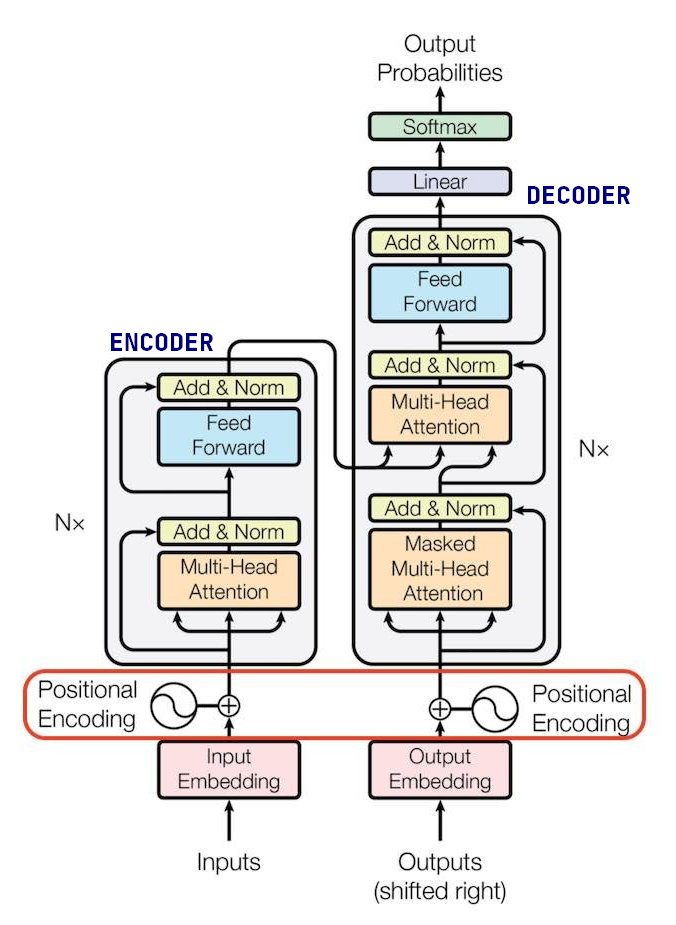

# 2 Preparación del Encoder y el Decoder

## 2.1 Tokenización

Para construir nuestro modelo Transformer, utilizaremos el conjunto de datos *cnn_dailymail* y el tokenizador *t5-small*. El objetivo será entrenar un Transformer para tareas de resumen automático de texto.

In [1]:
from datasets import load_dataset

dataset = load_dataset("cnn_dailymail", "3.0.0")

print(dataset)
print(dataset["train"][0])

DatasetDict({
    train: Dataset({
        features: ['article', 'highlights', 'id'],
        num_rows: 287113
    })
    validation: Dataset({
        features: ['article', 'highlights', 'id'],
        num_rows: 13368
    })
    test: Dataset({
        features: ['article', 'highlights', 'id'],
        num_rows: 11490
    })
})
{'article': 'LONDON, England (Reuters) -- Harry Potter star Daniel Radcliffe gains access to a reported £20 million ($41.1 million) fortune as he turns 18 on Monday, but he insists the money won\'t cast a spell on him. Daniel Radcliffe as Harry Potter in "Harry Potter and the Order of the Phoenix" To the disappointment of gossip columnists around the world, the young actor says he has no plans to fritter his cash away on fast cars, drink and celebrity parties. "I don\'t plan to be one of those people who, as soon as they turn 18, suddenly buy themselves a massive sports car collection or something similar," he told an Australian interviewer earlier this month. 

In [2]:
from transformers import AutoTokenizer

Dado que el modelo incluye tanto *encoder* como *decoder* (cuyas funciones veremos más adelante), debemos tokenizar tanto el texto de entrada como el de salida. Además, esta tokenización debe cumplir las siguientes condiciones:

- En el conjunto de datos, los textos tienen longitudes variables y, por lo tanto, generan secuencias de distinta longitud. Sin embargo, el modelo requiere longitudes fijas. Por ello, debemos completar las secuencias cortas con un token de relleno (*padding*) y truncar las más largas hasta una longitud máxima (*truncation*). En este caso, usaremos 512 tokens para el *encoder* y 128 para el *decoder*, junto con sus respectivas máscaras de atención.
- El modelo debe distinguir qué partes del texto corresponden a la entrada (*article*) y cuáles al objetivo (*highlights*).

> <span style="font-size: 2em; color: #f4b1df;">&#xf0ebf; </span> <span style="font-size: 1.5em; color: #f4b1df;">**Máscaras de atención**</span>
>
> En los modelos Transformer, las máscaras de atención indican qué tokens deben considerarse y cuáles deben ignorarse durante el cálculo de atención. Por ejemplo, si un texto tiene 3 tokens y el modelo espera una longitud de 8, se añaden tokens `<pad>` y la máscara marca esas posiciones para que no influyan en el cálculo.
>
> Input IDs:
> [I, like, pizza, `<pad>`, `<pad>`, `<pad>`, `<pad>`, `<pad>`]
>
> Attention Mask:
> [1, 1, 1, 0, 0, 0, 0, 0]
>
> Además, en el *decoder* se utiliza una máscara adicional llamada *máscara de atención causal*, que veremos en la sección 4.1 (*masked multi-head attention*), junto con su funcionamiento e implementación.

In [3]:
tokenizer = AutoTokenizer.from_pretrained("t5-small")

def preprocess(data):
    # Procesar Encoder Input
    model_input = tokenizer(
        data["article"],
        max_length=512,
        truncation=True,
        padding="max_length"
    )
    # Procesar Decoder Labels
    labels = tokenizer(
        data["highlights"],
        max_length=128,
        truncation=True,
        padding="max_length"
    )
    # Asignar inputs y máscaras
    model_input["labels"] = labels["input_ids"]
    # Esta es la máscara para que el encoder ignore el padding
    model_input["encoder_attention_mask"] = model_input["attention_mask"] 
    # Esta es la máscara para que el decoder ignore el padding de los labels
    model_input["decoder_attention_mask"] = labels["attention_mask"]
    
    return model_input

tokenized_dataset = dataset.map(preprocess, batched=True)
tokenized_dataset.set_format(type='torch',
                columns=['input_ids', 'encoder_attention_mask', 'decoder_attention_mask',  'labels'])

In [4]:
tokenizer.vocab_size

32100

In [5]:
tokenized_dataset

DatasetDict({
    train: Dataset({
        features: ['article', 'highlights', 'id', 'input_ids', 'attention_mask', 'labels', 'encoder_attention_mask', 'decoder_attention_mask'],
        num_rows: 287113
    })
    validation: Dataset({
        features: ['article', 'highlights', 'id', 'input_ids', 'attention_mask', 'labels', 'encoder_attention_mask', 'decoder_attention_mask'],
        num_rows: 13368
    })
    test: Dataset({
        features: ['article', 'highlights', 'id', 'input_ids', 'attention_mask', 'labels', 'encoder_attention_mask', 'decoder_attention_mask'],
        num_rows: 11490
    })
})

In [6]:
test = tokenized_dataset['train'][1]
test['input_ids'].size(), test['encoder_attention_mask'].size(), test['decoder_attention_mask'].size(), test['labels'].size()

(torch.Size([512]), torch.Size([512]), torch.Size([128]), torch.Size([128]))

Las longitudes son $T = 512$ para el *encoder* y $T = 128$ para el *decoder*.

In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [8]:
# embedding
embedding = nn.Embedding(num_embeddings=tokenizer.vocab_size, embedding_dim=512)
embedding(test['input_ids']).size()   # T x C

torch.Size([512, 512])

### Tokens especiales

Los tokens especiales se emplean para señalar partes específicas de la entrada y de la salida. A continuación, mostramos los que utiliza `t5-small`:

In [9]:
tokenizer.decode(0), tokenizer.decode(1), tokenizer.decode(2)

('<pad>', '</s>', '<unk>')

In [10]:
tokenizer.pad_token_id, tokenizer.eos_token_id, tokenizer.unk_token_id

(0, 1, 2)

| Token     | Función                                         |
| --------- | ----------------------------------------------- |
| `<pad>`   | Relleno (padding) y también inicio del decoder  |
| `</s>`    | Fin de secuencia (EOS)                          |
| `<unk>`   | Token desconocido                               |
| (sin BOS) | El decoder arranca sin token especial explícito |

In [ ]:
for i in range(5):
    emb = tokenized_dataset['train'][i]
    # Observación: todas las secuencias terminan en 1 (token EOS en T5).
    print(emb['input_ids'][:5], "... ", emb['input_ids'][-5:])

tensor([  301, 24796,  4170,     6,  2789]) ...  tensor([   96, 29835, 16575,   976,     1])
tensor([11953,    31,     7,  2232,    10]) ...  tensor([11, 34, 31,  7,  1])
tensor([    3, 17684,  4171,  2965, 28260]) ...  tensor([4716,    5,  216,  243,    1])
tensor([  549, 21337,  2365, 16270,    41]) ...  tensor([ 102,    7, 3641,  383,    1])
tensor([   41,   254, 17235,    61,  1636]) ...  tensor([  8, 540, 751,   5,   1])


## 2.2 Codificaciones posicionales (Positional Encodings)

Las *positional encodings* permiten incorporar información de orden en las secuencias de entrada y constituyen un componente esencial de los Transformers, ya que tanto la atención por producto punto escalado como las capas totalmente conectadas son invariantes a permutaciones. <font color = '#50d8fa'>En otras palabras, sin codificación posicional, el modelo no distinguiría el orden de las palabras y las representaciones basadas en atención perderían información clave</font>.

> Los Transformers permiten que una misma palabra tenga representaciones distintas según su posición, al sumar un vector posicional a los embeddings de entrada al inicio de los bloques de *encoder* y *decoder*.

En la arquitectura original, la codificación posicional es sinusoidal y se define como:

$$\Large
\begin{aligned}
PE_{(i,2k)}=\sin\left(pos/10\,000^{2k/d_{model}}\right)\\
PE_{(i,2k+1)}=\cos\left(pos/10\,000^{2k/d_{model}}\right)
\end{aligned}
$$

- $i$ representa la posición del token en la secuencia.
- $k$ representa la dimensión del vector posicional. Se elige para que coincida con la dimensión de los embeddings de entrada y pueda sumarse directamente a ellos.

Como $10\,000$ es un valor grande, la formulación también puede expresarse así:

$$\Large
\begin{aligned}
PE_{(i,2k)}=\sin\left(pos\cdot e^{(2k/d_{model})(-\log 10\,000)}\right)\\
PE_{(i,2k+1)}=\cos\left(pos\cdot e^{(2k/d_{model})(-\log 10\,000)}\right)
\end{aligned}
$$

<font color = '#50d8fa'>El uso de funciones sinusoidales evita que las codificaciones crezcan sin control</font>. Si se usaran posiciones absolutas simples (1, 2, 3, ..., n), en secuencias largas las posiciones finales tenderían a dominar la representación.

### 2.2.1 Codificaciones posicionales absolutas

Corresponden a la variante anterior: asignan un vector fijo a cada posición absoluta y, por tanto, son sensibles a desplazamientos en la oración.

### 2.2.2 Codificaciones posicionales relativas

En este caso, el modelo representa la distancia relativa entre tokens, por lo que la codificación es más robusta frente a desplazamientos globales de la secuencia.

In [ ]:
class AddPositionEncoding(nn.Module):
    def __init__(self, T, C):
        super().__init__()
        pe = torch.zeros(T, C)
        position = torch.arange(0, T, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, C, 2).float() * (-torch.log(torch.tensor(10_000.0)) / C))
        
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        
        # No es un parámetro entrenable; se registra como buffer.
        self.register_buffer('pe', pe)

    def forward(self, x):
        # x tiene forma: [Batch, Seq_Len, Emb_Dim]
        # Se aplica la codificación posicional hasta Seq_Len.
        x = x + self.pe[:x.size(1), :]
        return x

> <span style="font-size: 2em; color: #f4b1df;">&#xf0ebf; </span> <span style="font-size: 1.5em; color: #f4b1df;">**Importancia de hacer el cálculo en el `__init__`**</span>
>
> Como el vector posicional es fijo, conviene calcularlo en el `__init__` para evitar recalcularlo cada vez que se ejecuta `forward` (lo cual ocurre en cada paso de entrenamiento). Además, `register_buffer` le indica a PyTorch que `pe` es un tensor que pertenece al módulo, pero no es un parámetro entrenable.

In [13]:
# Si tenemos un tensor con dimensiones (B x T x C) = (3 , 4, 15)

x = torch.randn(3, 4, 30)  # Ejemplo de tensor con dimensiones (B x T x C)
B, T, C = x.shape  # B=3, T=4, C=15

In [14]:
position = AddPositionEncoding(T=T, C=C)
position_encoding = position(x)
print(position_encoding.shape)  # Debería ser (B, T, C)

torch.Size([3, 4, 30])


In [15]:
x_positional = x + position_encoding

# 3 Encoding

El objetivo del bloque codificador es transformar una entrada secuencial $\mathbf{X} = (x^{(1)}, x^{(2)}, ..., x^{(T)})$ en una representación continua $\mathbf{Z} = (z^{(1)}, z^{(2)}, ..., z^{(T)})$, que luego se entrega al decodificador.

Cada capa codificadora contiene dos subcapas principales:
1. Una subcapa de autoatención multi-cabezal.
2. Una subcapa totalmente conectada (*feed-forward*).

## 3.1 Generación de matrices de consulta, clave y valor

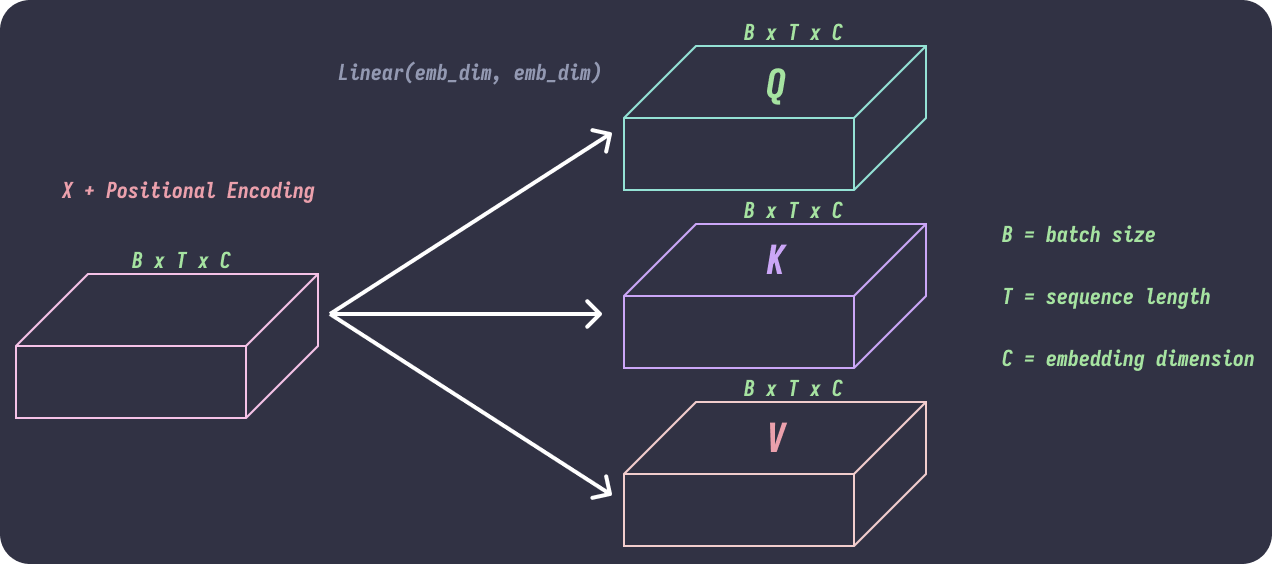

Para obtener $Q$, $K$ y $V$, en lugar de aplicar tres transformaciones lineales independientes, podemos proyectar $x + PE$ con una única capa lineal `nn.Linear(C, 3*C)` y, posteriormente, dividir el resultado en tres partes.

## 3.2 Multi-head attention

La *multi-head attention* es una extensión de la atención por producto punto escalado. En este mecanismo se construyen tres representaciones de la entrada: consulta ($Q$), clave ($K$) y valor ($V$). En el contexto multi-cabezal, cada conjunto $(Q, K, V)$ actúa como una cabeza de atención; de forma análoga a una CNN con múltiples filtros, varias cabezas permiten capturar patrones complementarios.

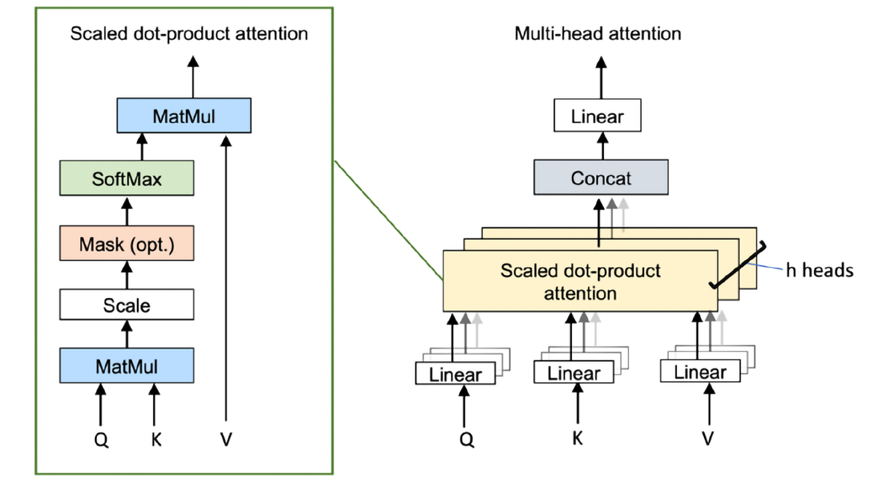

El proceso puede resumirse en los siguientes pasos:

- `q`, `k` y `v` tienen dimensión $(B, T, C)$. Cada tensor se divide en `h` partes iguales, donde `h` es el número de cabezas: $B\,T\,C \rightarrow B\,T\,(h\,d) \rightarrow B\,h\,T\,d$.
- Se aplica la atención escalada: $$\mathbf{Y}=\mathrm{Attention}(\mathbf{Q},\mathbf{K},\mathbf{V})=\mathrm{softmax}\left(\frac{\mathbf{Q}\mathbf{K}^{T}}{\sqrt{d_k}}\right)\mathbf{V}.$$ El resultado intermedio tiene dimensión $(B, h, T, d)$.
- Se concatenan las salidas de todas las cabezas para recuperar $(B, T, h\,d) = (B, T, C)$.
- Finalmente, se aplica una proyección lineal sobre la salida concatenada.

*De forma opcional, puede añadirse una capa de dropout tras la atención para reducir el sobreajuste.*

```python
class MultiHeadAttention(nn.Module):
    def __init__(self, emb_dim, num_heads, dropout=0.1):
        super().__init__()
        assert emb_dim % num_heads == 0
        self.d_k = emb_dim // num_heads
        self.num_heads = num_heads
        
        # Instancia el dropout aquí, no en el forward
        self.dropout = nn.Dropout(dropout) 

        self.q_linear = nn.Linear(emb_dim, emb_dim)
        self.k_linear = nn.Linear(emb_dim, emb_dim)
        self.v_linear = nn.Linear(emb_dim, emb_dim)
        self.out_linear = nn.Linear(emb_dim, emb_dim)

    def forward(self, q, k, v, attn_mask=None, decoder_mask=False):
        # 1. Proyecciones lineales
        q = self.q_linear(q)
        k = self.k_linear(k)
        v = self.v_linear(v)

        # 2. Rearrange para multi-head
        q = einops.rearrange(q, 'B T (h d) -> B h T d', h=self.num_heads)
        k = einops.rearrange(k, 'B T (h d) -> B h T d', h=self.num_heads)
        v = einops.rearrange(v, 'B T (h d) -> B h T d', h=self.num_heads)

        # 3. Scaled dot-product
        att = (q @ k.transpose(-2, -1)) / (self.d_k ** 0.5) # B x h x T x T

        # 4. Aplicar máscaras de atención
        if attn_mask is not None:
            # cada máscara de atención tiene forma B x T, batch x longitud de secuencia
            attn_mask = einops.rearrange(attn_mask, 'B T -> B 1 1 T')  # Expandir para broadcasting
            att = att.masked_fill(attn_mask == 0, -1e9)
        
        if decoder_mask:
            T = att.size(-2)
            # Creamos la máscara causal dinámicamente según el dispositivo de 'att'
            causal_mask = torch.tril(torch.ones(T, T, device=att.device)).view(1, 1, T, T)
            att = att.masked_fill(causal_mask == 0, -1e9) # Usamos -1e9 en lugar de -inf para estabilidad

        # 5. Softmax y Dropout
        attn_weights = F.softmax(att, dim=-1)
        attn_weights = self.dropout(attn_weights) # Usa la instancia definida en __init__

        # 6. Salida
        attn_output = attn_weights @ v
        concat = einops.rearrange(attn_output, 'B h T d -> B T (h d)')
        return self.out_linear(concat)
```

## 3.3 Flash Attention

Flash Attention es una optimización de la atención por producto punto escalado que reduce el consumo de memoria y acelera el entrenamiento. En lugar de materializar la matriz de atención completa, realiza el cálculo por bloques, lo que permite procesar secuencias más largas sin agotar memoria.

En un flujo convencional de multiplicación de matrices, el proceso es el siguiente:

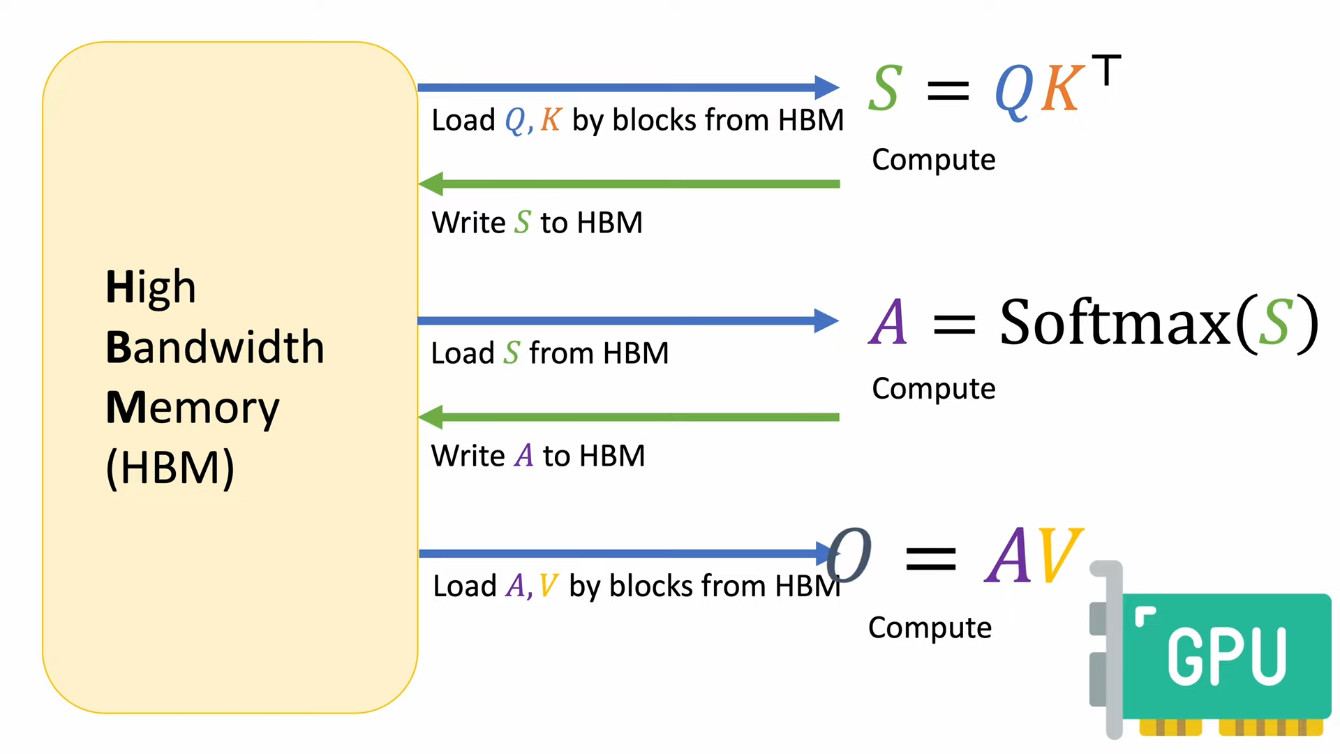

Las diferencias de velocidad entre tipos de memoria se observan en la siguiente figura:

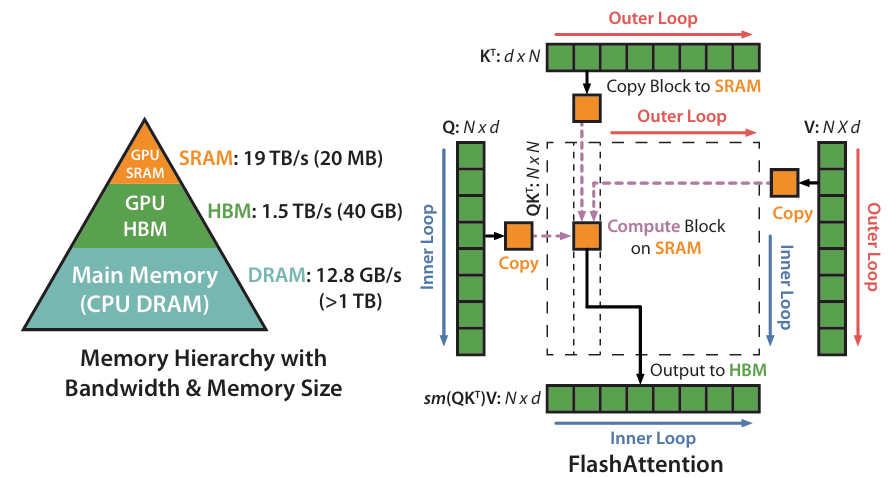

La idea central de Flash Attention es maximizar el uso de memoria rápida (por ejemplo, SRAM), calculando la atención por bloques.

PyTorch lo implementa mediante `F.scaled_dot_product_attention`. El resultado matemático es equivalente al de la formulación estándar.

In [16]:
import einops

In [17]:
class MultiHeadAttention(nn.Module):
    def __init__(self, emb_dim, num_heads, dropout=0.1):
        super().__init__()
        assert emb_dim % num_heads == 0
        self.d_k = emb_dim // num_heads
        self.num_heads = num_heads
        self.dropout = nn.Dropout(dropout) 

        self.q_linear = nn.Linear(emb_dim, emb_dim) 
        self.k_linear = nn.Linear(emb_dim, emb_dim)
        self.v_linear = nn.Linear(emb_dim, emb_dim)
        self.out_linear = nn.Linear(emb_dim, emb_dim)

    def forward(self, q, k, v, attn_mask=None, decoder_mask=False):
        # Proyectar Q, K, V y dividir en múltiples cabezas
        q = self.q_linear(q)
        k = self.k_linear(k)
        v = self.v_linear(v)

        # Multi head: dividir el embedding en num_heads partes y reorganizar para el cálculo de atención
        q = einops.rearrange(q, 'B T (h d) -> B h T d', h=self.num_heads)
        k = einops.rearrange(k, 'B T (h d) -> B h T d', h=self.num_heads)
        v = einops.rearrange(v, 'B T (h d) -> B h T d', h=self.num_heads)

        # Aplicar máscaras de atención
        if attn_mask is not None:
            # attn_mask: [B, T] con 1=válido, 0=padding
            #! scaled_dot_product_attention espera True donde se PERMITE atender, y False donde se BLOQUEA
            attn_mask = einops.rearrange(attn_mask, 'B T -> B 1 1 T').bool()

        # flash attention
        attn_output = F.scaled_dot_product_attention(
            q, k, v, 
            attn_mask=attn_mask,
            is_causal=decoder_mask,
            dropout_p=self.dropout.p if self.training else 0.0
        )
        concat = einops.rearrange(attn_output, 'B h T d -> B T (h d)')
        return self.out_linear(concat)

En el código anterior incorporamos `mask` como parámetro opcional para soportar la capa *Masked Multi-head Attention* del decodificador, cuya formulación es:

$$\Large \text{MaskedAttention}(Q, K, V) = \text{softmax}\left(\frac{QK^T + M}{\sqrt{d_k}}\right)V$$

El propósito de esta capa se explica en la sección siguiente.

In [18]:
multi_head_attn = MultiHeadAttention(emb_dim=C, num_heads=3)
output = multi_head_attn(x_positional, x_positional, x_positional)
output.shape

torch.Size([3, 4, 30])

## 3.4 Feed-forward

Este bloque consta de:
- Una capa totalmente conectada `nn.Linear(C, 4*C)` (en el artículo original se utiliza `4*C`, aunque es un hiperparámetro ajustable).
- Una función de activación `nn.ReLU()`.
- Una segunda capa totalmente conectada `nn.Linear(4*C, C)`.

De forma opcional, cuando se dispone de pocos datos y existe riesgo de sobreajuste, se añade una capa de *dropout* después de las capas lineales.

In [19]:
class FeedForward(nn.Module):
    def __init__(self, emb_dim, expansion_factor=4, dropout=0.1):
        super().__init__()
        self.linear1 = nn.Linear(emb_dim, expansion_factor * emb_dim)
        self.linear2 = nn.Linear(expansion_factor * emb_dim, emb_dim)
        # optional dropout layer
        self.drop = nn.Dropout(p=dropout)

    def forward(self, x):
        return self.drop(self.linear2(F.relu(self.linear1(x))))

## 3.5 Capa Encoder

Con los componentes anteriores, ya podemos construir una capa completa del *encoder*.

In [20]:
class EncoderTransformer(nn.Module):
    def __init__(self, emb_dim, num_heads, dropout=0.1):
        super().__init__()
        self.self_attn = MultiHeadAttention(emb_dim, num_heads)
        self.ff = FeedForward(emb_dim)
        self.norm1 = nn.LayerNorm(emb_dim)
        self.norm2 = nn.LayerNorm(emb_dim)
        self.drop = nn.Dropout(dropout)

    def forward(self, x, attn_mask):
        # Self-attention
        attn_output = self.self_attn(x, x, x, attn_mask)
        x = self.norm1(x + self.drop(attn_output))  # Residual connection + LayerNorm
        # Feed-forward
        ff_output = self.ff(x)
        x = self.norm2(x + ff_output)  # Residual connection + LayerNorm
        return x

# 4 Decoding

Además de las dos subcapas ya introducidas en el *encoder* (multi-head attention y capa totalmente conectada), el decodificador incorpora una subcapa adicional de *masked multi-head attention*.

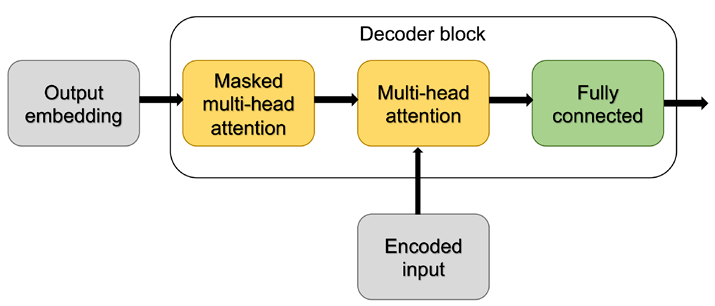

## 4.1 Masked Multi-head Attention

<font color = '#50d8fa'>La atención enmascarada (*masked attention*) es una variante del mecanismo de atención en la que solo se expone al modelo una parte de la secuencia, ocultando ciertas posiciones</font>. Durante el entrenamiento, en la posición *i* solo se proporcionan los tokens correctos de salida en las posiciones *1, ..., i-1*. Los tokens futuros se enmascaran para evitar fugas de información. Esto es coherente con la generación autorregresiva: en inferencia solo podemos condicionar al modelo con lo que ya fue generado.

Su expresión es:

$$\Large \text{MaskedAttention}(Q, K, V) = \text{softmax}\left(\frac{QK^T + M}{\sqrt{d_k}}\right)V$$

Interpretación de $M$:

1. **Causalidad:** para cada posición $i$, solo se permite atender a posiciones $j$ con $j \leq i$.
2. **Valores de la máscara:**
- Si la conexión está permitida (pasado y presente), en $M$ se coloca **0**.
- Si la conexión apunta al futuro, en $M$ se coloca **$-\infty$**.
3. **Efecto del softmax:** un valor muy negativo (como $-\infty$) se transforma en probabilidad **0** tras aplicar *softmax*.

Por ejemplo, para la secuencia "El gato duerme como un ángel", la matriz de afinidad antes del *softmax* (filas = $Q$, columnas = $K$) sería:

| (T x T) | El | gato | duerme | como | un | ángel |
| --- | --- | --- | --- | --- | --- | --- |
| **El** | 0.95 | $-\infty$ | $-\infty$ | $-\infty$ | $-\infty$ | $-\infty$ |
| **gato** | 0.85 | 0.90 | $-\infty$ | $-\infty$ | $-\infty$ | $-\infty$ |
| **duerme** | 0.80 | 0.85 | 0.90 | $-\infty$ | $-\infty$ | $-\infty$ |
| **como** | 0.75 | 0.80 | 0.85 | 0.90 | $-\infty$ | $-\infty$ |
| **un** | 0.70 | 0.75 | 0.80 | 0.85 | 0.90 | $-\infty$ |
| **ángel** | 0.65 | 0.85 | 0.75 | 0.80 | 0.85 | 0.90 |

- Al procesar **"El"**, el modelo solo puede atender a esa misma posición.
- Al procesar **"gato"**, puede atender a "El" y "gato".
- Al procesar **"duerme"**, ya dispone de todo el contexto previo.

## 4.2 Resto del bloque de decodificación

- A continuación, las salidas de la subcapa enmascarada y del *encoder* alimentan una subcapa de *multi-head attention* cruzada.
- Posteriormente, la salida pasa por una capa totalmente conectada.
- <font color = '#e6829f'></font> <span style="background-color: #e6829f; color: #1e1e2e;">Importante</span><font color = '#e6829f'> En la atención cruzada entre encoder y decoder, la salida del *encoder* se utiliza como `key` y `value`, mientras que la salida previa del *decoder* se utiliza como `query`, tras sus respectivas proyecciones lineales.</font>

Como el objetivo del decodificador es generar la secuencia de salida prediciendo el siguiente token, se construyen pares entrada-objetivo de esta forma:

| entrada | target |
|---|---|
| El | gato |
| El gato | duerme |
| El gato duerme | como |
| El gato duerme como | un |
| El gato duerme como un | ángel |

Por ello, en la entrada del *decoder* se omite el último token y en el *target* se omite el primero, tal como se observa en la figura siguiente:

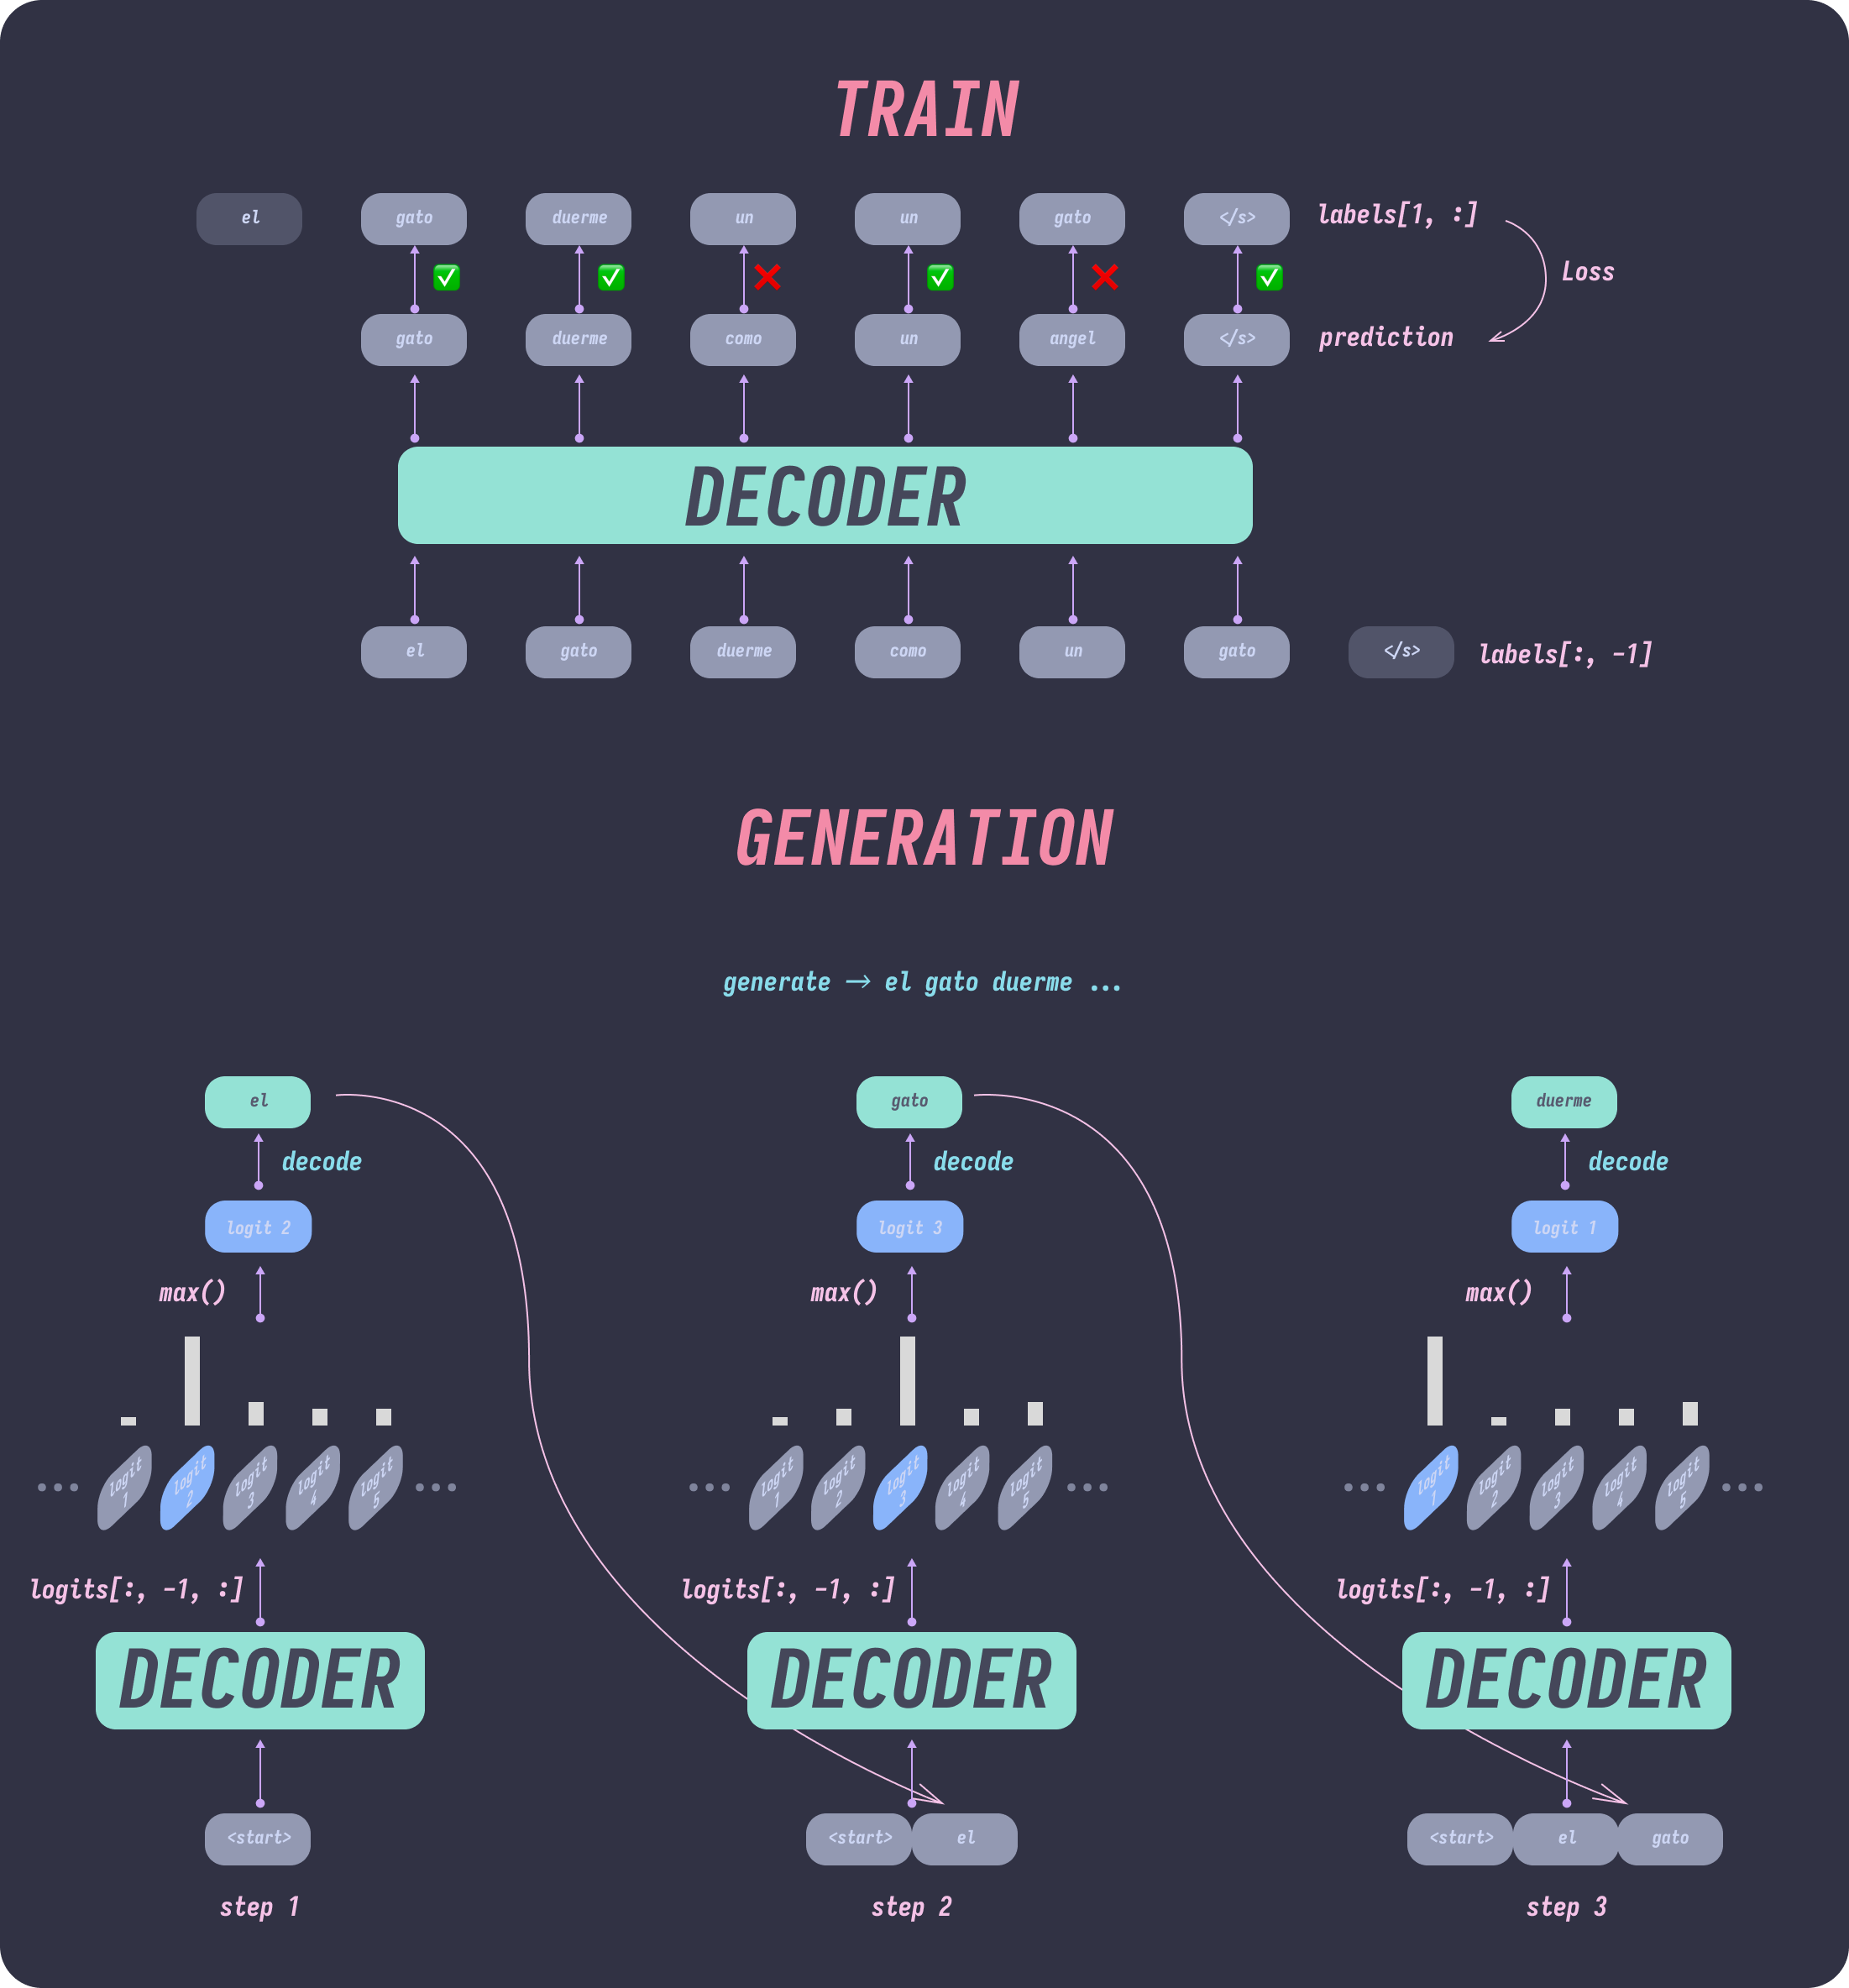

Este esquema se aplica tanto en entrenamiento como en inferencia, con una diferencia clave:

- En entrenamiento, el cálculo se realiza en paralelo.
- En inferencia, la generación es secuencial (un token por paso). Esto introduce recomputación, por lo que se emplea *KV-cache*.

## 4.3 KV-cache

KV-cache es una técnica de optimización utilizada en inferencia para evitar recalcular las matrices de <font color = '#50d8fa'>clave y valor (K, V)</font> en cada paso de generación. En lugar de recomputarlas sobre toda la secuencia acumulada, se almacenan en caché y se reutilizan, reduciendo de forma significativa la latencia, especialmente en secuencias largas.

El KV-cache se aplica únicamente en el *decoder*.

```python
...
    # ── Inferencia: KV-cache activo ───────────────────────────────────────
    if kv_cache is not None:
        k = torch.cat([kv_cache['k'], k], dim=1)
        v = torch.cat([kv_cache['v'], v], dim=1)
        new_cache = {'k': k.detach(), 'v': v.detach()}
    else:
        new_cache = None  # entrenamiento: no se construye ni se retorna nada útil
...
# cuando hay cache activo, is_causal debe ser False
    effective_causal = decoder_mask and (kv_cache is None)

    attn_output = F.scaled_dot_product_attention(
        q, k, v,
        attn_mask=attn_mask,
        is_causal=effective_causal,
        dropout_p=self.dropout.p if self.training else 0.0
    )
...
```

Durante la inferencia, cuando `kv_cache` está activo, `decoder_mask` se establece en `False`, ya que solo se procesa el token más reciente y el contexto anterior ya está disponible en caché.

Con esta idea, la nueva clase de atención con KV-cache queda de la siguiente forma:

In [ ]:
class MultiHeadAttentionKVCache(MultiHeadAttention):
    def forward(self, q, k, v, attn_mask=None, decoder_mask=False, kv_cache=None):
        q = self.q_linear(q)
        k = self.k_linear(k)
        v = self.v_linear(v)

        # Inferencia con KV-cache activo.
        if kv_cache is not None:
            # Se concatena sobre la dimensión temporal (T), donde están los tokens.
            k = torch.cat([kv_cache['k'], k], dim=-2) # B x T_cache x (h*d)
            v = torch.cat([kv_cache['v'], v], dim=-2) # B x T_cache x (h*d)
            print("KV Cache activo: k.shape =", k.shape, "v.shape =", v.shape)
            new_cache = {'k': k.detach(), 'v': v.detach()}
        else:
            new_cache = None  # Entrenamiento: no se construye ni retorna caché útil.

        q = einops.rearrange(q, 'B T (h d) -> B h T d', h=self.num_heads)
        k = einops.rearrange(k, 'B T (h d) -> B h T d', h=self.num_heads)
        v = einops.rearrange(v, 'B T (h d) -> B h T d', h=self.num_heads)

        if attn_mask is not None:
            attn_mask = einops.rearrange(attn_mask, 'B T -> B 1 1 T').bool()

        # Con caché activa, is_causal debe ser False.
        effective_causal = decoder_mask and (kv_cache is None)
        # scaled_dot_product_attention no permite decoder_mask=True y attn_mask simultáneamente.
        effective_attn_mask = None if effective_causal else attn_mask
        # Q x K^T ==> (B x h x T x d) x (B x h x T_cache x d) --> B x h x T x T_cache
        # x V ==> (B x h x T x T_cache) x (B x h x T_cache x d) --> B x h x T x d
        attn_output = F.scaled_dot_product_attention(
            q, k, v,
            attn_mask=effective_attn_mask,
            is_causal=effective_causal,
            dropout_p=self.dropout.p if self.training else 0.0
        )
        concat = einops.rearrange(attn_output, 'B h T d -> B T (h d)')
        return self.out_linear(concat), new_cache # B T C

## 4.4 Funciones del encoder y del decoder

| **Componente** | **Función principal** | **Tipo de atención** | **Objetivo** | **Ejemplos** |
| -------------- | --------------------- | -------------------- | ------------ | ------------ |
| **Encoder**    | Capturar significado y relaciones globales en la secuencia de entrada. | Bidireccional | Comprender / clasificar | BERT |
| **Decoder**    | Generar la secuencia de salida token a token. | Unidireccional (enmascarada) | Generar / predecir | GPT-4 / Llama |
| **Ambos**      | Combinar comprensión y generación en tareas de transformación secuencial. | Mixta | Transformar secuencias | T5 / BART |

# 5 Layer Normalization

- Mientras que *batch normalization* es una opción habitual en visión por computador,
- *layer normalization* suele preferirse en PLN, donde la longitud de las secuencias puede variar. La siguiente figura ilustra sus diferencias principales:

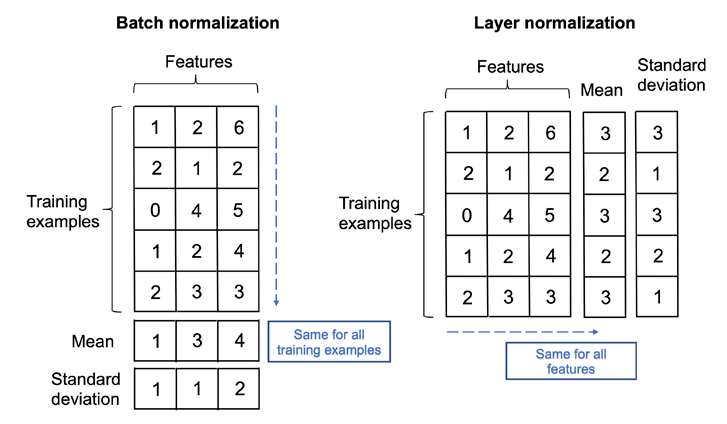

- *Batch normalization* normaliza cada característica utilizando estadísticas calculadas sobre el minibatch.
- *Layer normalization*, en cambio, normaliza cada ejemplo de manera independiente a través de sus dimensiones de características.

## 5.1 Layer Normalization vs. Batch Normalization

- *Layer normalization* calcula media y desviación estándar por ejemplo, reduciendo la dependencia del tamaño del minibatch.
- A diferencia de *batch normalization*, funciona bien con minibatches pequeños y secuencias de longitud variable.

No obstante, debe tenerse en cuenta que la arquitectura original del Transformer no trabaja con longitudes completamente libres (las secuencias se rellenan cuando es necesario) y, además, no incorpora recurrencia como las RNN.

**¿Por qué, entonces, se prefiere normalización por capas frente a normalización por lotes?**

Los Transformers suelen entrenarse en corpus muy grandes y en entornos altamente paralelizables. En ese contexto, *batch normalization* introduce dependencia entre ejemplos del lote, mientras que *layer normalization* evita esa dependencia y resulta más natural para esta arquitectura.

In [22]:
class DecoderTransformer(nn.Module):
    def __init__(self, emb_dim, num_heads, dropout=0.1):
        super().__init__()
        self.self_attn = MultiHeadAttentionKVCache(emb_dim, num_heads)
        self.enc_dec_attn = MultiHeadAttentionKVCache(emb_dim, num_heads)
        self.ff = FeedForward(emb_dim)
        self.norm1 = nn.LayerNorm(emb_dim)
        self.norm2 = nn.LayerNorm(emb_dim)
        self.norm3 = nn.LayerNorm(emb_dim)
        self.drop = nn.Dropout(dropout)

    def forward(self, x, enc_output, enc_mask, dec_mask, self_cache=None, cross_cache=None):
        # 1. Masked self-attention (causal) sobre el target
        attn_output, new_self_cache = self.self_attn(x, x, x,
            attn_mask=dec_mask,
            decoder_mask=True,
            kv_cache=self_cache
        )
        x = self.norm1(x + self.drop(attn_output))
        # 2. Cross-attention: query = decoder, key/value = encoder
        enc_dec_output, new_cross_cache = self.enc_dec_attn(x, enc_output, enc_output,
            attn_mask=enc_mask,
            decoder_mask=False,
            kv_cache=cross_cache
        )
        x = self.norm2(x + self.drop(enc_dec_output))

        # 3. Feed-forward
        x = self.norm3(x + self.ff(x))   # size: [B, T_dec, C]
        return x, new_self_cache, new_cross_cache

# 6 Integración: Transformer completo

Como el *decoder* es el encargado de generar la secuencia de salida, el *encoder* se ejecuta una única vez para procesar la entrada, tanto en entrenamiento como en inferencia.

En inferencia, al usar KV-cache, la arquitectura operativa del *decoder* cambia ligeramente:

- En entrenamiento, el *decoder* se ejecuta una sola vez sobre toda la secuencia objetivo (implementado en `forward`).
- En inferencia, el *decoder* opera de forma secuencial, generando un token por paso (usando el último logit, `logits[:, -1, :]`) y actualizando el KV-cache. Por ello, se implementa en un método separado (`decode`).

In [23]:
class CustomTransformer(nn.Module):
    def __init__(self, num_layers, emb_dim, num_heads, vocab_size, dropout=0.1):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim)
        self.enc_position = AddPositionEncoding(T=512, C=emb_dim)
        self.dec_position = AddPositionEncoding(T=128, C=emb_dim)
        self.emb_dropout = nn.Dropout(dropout)

        self.encoders = nn.ModuleList(
            [EncoderTransformer(emb_dim, num_heads, dropout) for _ in range(num_layers)]
        )
        self.decoders = nn.ModuleList(
            [DecoderTransformer(emb_dim, num_heads, dropout) for _ in range(num_layers)]
        )
        self.linear_out = nn.Linear(emb_dim, vocab_size)

        # Inicialización de pesos estándar para transformers
        self._init_weights()

    def _init_weights(self):
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)

    def forward(self, source, target, source_mask, target_mask):
        target = self.emb_dropout(self.dec_position(self.embedding(target)))
        enc_output = self.encode(source, source_mask)

        # --- Decoder con N capas
        dec_output = target
        for decoder in self.decoders:
            dec_output, _, _ = decoder(dec_output, enc_output, source_mask, target_mask)

        logits = self.linear_out(dec_output)  # [B, T, C]
        return logits

    # Encoder: es el mismo para entrenamiento y generación:
    def encode(self, source, source_mask):
        # Embeddings + positional encoding
        source = self.emb_dropout(self.enc_position(self.embedding(source)))
        # Encoder: N capas
        for encoder in self.encoders:
            source = encoder(source, source_mask)
        return source

    ### ---FUNCION USADA SOLO CUANDO HAY KV-CACHE ACTIVO--- ###
    # --------- decoder inference --- con KV-cache --------- ##
    def decode(self, token_id, enc_output, enc_mask, caches, step):
        # Embedding + positional encoding solo para el token nuevo
        x = self.embedding(token_id)                     # [B, 1, emb_dim]
        x = x + self.dec_position.pe[step:step+1, :]    # PE de la posición actual
        
        # Decoder con N capas
        new_caches = []
        for i, decoder in enumerate(self.decoders):
            x, new_self_cache, new_cross_cache = decoder(
                x,
                enc_output,
                enc_mask,
                dec_mask = None,
                self_cache = caches[i]['self'],
                cross_cache = caches[i]['cross']
            )
            new_caches.append({'self': new_self_cache, 'cross': new_cross_cache})

        logits = self.linear_out(x[:, -1, :])  # [Batch, Vocab]
        return logits, new_caches

# 7 Resumen de texto

Con la arquitectura completa definida, podemos evaluar el modelo Transformer en el conjunto de noticias que preparamos anteriormente.

In [24]:
# make a dataloader
from torch.utils.data import DataLoader

train_dataloader = DataLoader(
    tokenized_dataset["train"],
    batch_size=64,
    shuffle=True,
    num_workers=8,
    pin_memory=True,
    prefetch_factor=2
)
test_dataloader = DataLoader(
    tokenized_dataset["test"],
    batch_size=64,
    shuffle=False,
    num_workers=8,
    pin_memory=True,
    prefetch_factor=2
)

## 7.1 Optimizaciones para acelerar el entrenamiento

- Usar `torch.compile` con `mode='max-autotune'` para mejorar el rendimiento.
- Configurar `torch.set_float32_matmul_precision('high')` para optimizar multiplicaciones de matrices con buena relación precisión-rendimiento.
- Usar `with torch.autocast(device_type='cuda', dtype=torch.bfloat16)` para habilitar precisión mixta, reducir uso de memoria y acelerar el cómputo en GPU compatibles con `bfloat16`.

In [ ]:
torch.set_float32_matmul_precision('high')

model = CustomTransformer(
    num_layers=10,
    emb_dim=512,
    num_heads=8,
    vocab_size=tokenizer.vocab_size,
    dropout=0.1
).to("cuda")

model = torch.compile(model, mode= 'max-autotune')

In [26]:
from transformers import get_cosine_schedule_with_warmup

In [ ]:
num_epochs = 20
num_training_steps = num_epochs * len(train_dataloader)
num_warmup_steps = num_training_steps // 10  # 10% de warmup

# AdamW con weight decay para regularización, y scheduler de cosine decay con warmup
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=0.01)
scheduler = get_cosine_schedule_with_warmup(
    optimizer,
    num_warmup_steps=num_warmup_steps,
    num_training_steps=num_training_steps
)
# loss function con ignore_index para que no compute el loss sobre los tokens de padding
loss_fn = nn.CrossEntropyLoss(ignore_index=tokenizer.pad_token_id, label_smoothing=0.1)

## 7.2 Funciones de entrenamiento y evaluación

A continuación, definimos las funciones `train` y `evaluate` para ejecutar el ciclo de optimización y medir el desempeño del modelo en validación.

In [28]:
def train(dataloader, device="cuda"):
    model.train()
    total_loss = 0
    for batch in dataloader:
        #### encoder input y encoder mask
        input_ids    = batch["input_ids"].to(device)
        enc_mask     = batch["encoder_attention_mask"].to(device)

        #### decoder input, decoder mask
        dec_mask_raw = batch["decoder_attention_mask"].to(device)
        labels       = batch["labels"].to(device)

        # labels y mask sin el último token para 
        dec_input  = labels[:, :-1]
        dec_mask   = dec_mask_raw[:, :-1]

        # decoder target = labels sin el primer token 
        # porque en loss, queremos predecir el próximo token.
        dec_target = labels[:, 1:]

        optimizer.zero_grad()

        with torch.autocast(device_type='cuda', dtype=torch.bfloat16):
            outputs = model(input_ids, dec_input, enc_mask, dec_mask)
            loss = loss_fn(
                outputs.reshape(-1, outputs.size(-1)),
                dec_target.reshape(-1)
            )
        loss.backward()
        # gradient clipping para estabilidad
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
    return total_loss / len(dataloader)

def evaluate(dataloader, device="cuda"):
    model.eval()
    total_loss = 0
    with torch.inference_mode():
        for batch in dataloader:
            input_ids    = batch["input_ids"].to(device)
            enc_mask     = batch["encoder_attention_mask"].to(device)
            dec_mask_raw = batch["decoder_attention_mask"].to(device)
            labels       = batch["labels"].to(device)

            dec_input  = labels[:, :-1]
            dec_target = labels[:, 1:]
            dec_mask   = dec_mask_raw[:, :-1]

            with torch.autocast(device_type='cuda', dtype=torch.bfloat16):
                outputs = model(input_ids, dec_input, enc_mask, dec_mask)
                loss = loss_fn(
                    outputs.reshape(-1, outputs.size(-1)),
                    dec_target.reshape(-1)
                )
            total_loss += loss.item()
    return total_loss / len(dataloader)

In [29]:
total_params = sum(p.numel() for p in model.parameters())
print(f"Parámetros: {total_params / 1e6:.1f}M")

Parámetros: 77.0M


In [30]:
torch.manual_seed(1)

for epoch in range(num_epochs):
    loss_train = train(train_dataloader)
    loss_valid = evaluate(test_dataloader)
    lr_actual  = scheduler.get_last_lr()[0]
    print(f'Epoch {epoch:02d}  train_loss: {loss_train:.4f}  val_loss: {loss_valid:.4f}  lr: {lr_actual:.2e}')

Epoch 00  train_loss: 7.2518  val_loss: 6.0693  lr: 3.33e-05
Epoch 01  train_loss: 5.8754  val_loss: 5.5196  lr: 6.67e-05
Epoch 02  train_loss: 5.4156  val_loss: 5.0800  lr: 1.00e-04
Epoch 03  train_loss: 5.0439  val_loss: 4.7507  lr: 9.97e-05
Epoch 04  train_loss: 4.7745  val_loss: 4.5529  lr: 9.87e-05
Epoch 05  train_loss: 4.5795  val_loss: 4.3944  lr: 9.70e-05
Epoch 06  train_loss: 4.4142  val_loss: 4.2599  lr: 9.47e-05
Epoch 07  train_loss: 4.2751  val_loss: 4.1571  lr: 9.18e-05
Epoch 08  train_loss: 4.1612  val_loss: 4.0854  lr: 8.83e-05
Epoch 09  train_loss: 4.0649  val_loss: 4.0333  lr: 8.43e-05
Epoch 10  train_loss: 3.9844  val_loss: 3.9948  lr: 7.99e-05
Epoch 11  train_loss: 3.9155  val_loss: 3.9520  lr: 7.50e-05
Epoch 12  train_loss: 3.8560  val_loss: 3.9186  lr: 6.98e-05
Epoch 13  train_loss: 3.8035  val_loss: 3.8880  lr: 6.43e-05
Epoch 14  train_loss: 3.7573  val_loss: 3.8637  lr: 5.87e-05
Epoch 15  train_loss: 3.7167  val_loss: 3.8434  lr: 5.29e-05
Epoch 16  train_loss: 3.

In [32]:
# save the model
torch.save(model.state_dict(), "custom/transformer_summarization.pth")

## 7.3 Función `summarize`

Esta función genera un resumen del texto de entrada usando el Transformer entrenado. El proceso es iterativo: produce un token por paso hasta alcanzar la longitud máxima o predecir el token EOS (*end of sequence*).

### Penalización por repetición

La penalización por repetición evita que el modelo produzca secuencias redundantes. Se implementa dividiendo los *logits* de los tokens ya generados por un factor (`repetition_penalty`). De este modo:

- **Tokens nuevos**: conservan sus *logits* originales y mantienen su probabilidad relativa.
- **Tokens repetidos**: ven reducidos sus *logits*, disminuyendo su probabilidad de volver a ser seleccionados.

En el código:

```python
for token_id in summary_ids[0].unique():
    next_token_logits[0, token_id] /= repetition_penalty
```

Por ejemplo, si `repetition_penalty=1.3` y un token tiene logit 10.0, tras la penalización queda en $10.0/1.3 \approx 7.7$, por lo que su selección es menos probable.

### Temperatura

La temperatura controla la diversidad durante la selección del siguiente token:

- **Temperatura < 1** (p. ej., 0.7): amplifica diferencias entre *logits*. El modelo se vuelve más conservador.
- **Temperatura = 1**: no modifica los *logits*.
- **Temperatura > 1** (p. ej., 1.5): suaviza diferencias entre *logits*. El modelo se vuelve más diverso.

En el código:

```python
if temperature != 1.0:
    next_token_logits = next_token_logits / temperature
```

Finalmente, se utiliza `argmax` para seleccionar el token de mayor logit (estrategia *greedy*):

```python
summary_ids = torch.tensor([[start]], device=device)

with torch.inference_mode():
    for _ in range(max_len):
```

```python
def summarize(model, text, tokenizer, max_len=150, device="cuda",
              temperature=1.0, repetition_penalty=1.3):
    model.eval()

    # 1. Tokenizar entrada del encoder
    inputs = tokenizer(
        text, return_tensors="pt",
        padding=True, truncation=True, max_length=512
    ).to(device)
    input_ids    = inputs["input_ids"]
    enc_attn_mask = inputs["attention_mask"]

    start = tokenizer.pad_token_id
    summary_ids = torch.tensor([[start]], device=device)

    with torch.inference_mode():
        for _ in range(max_len):
            dec_attn_mask = (summary_ids != tokenizer.pad_token_id).long()

            # 2. Forward pass
            outputs = model(input_ids, summary_ids, enc_attn_mask, dec_attn_mask)

            # 3. Logits del último token generado
            next_token_logits = outputs[:, -1, :]

            # 4. Penalización de repetición
            for token_id in summary_ids[0].unique():
                next_token_logits[0, token_id] /= repetition_penalty

            # 5. Temperatura (>1 más diverso, <1 más conservador)
            if temperature != 1.0:
                next_token_logits = next_token_logits / temperature

            next_token_id = torch.argmax(next_token_logits, dim=-1, keepdim=True)

            # 6. Concatenar token predicho
            summary_ids = torch.cat([summary_ids, next_token_id], dim=-1)

            # 7. Parar si predice EOS
            if next_token_id.item() == tokenizer.eos_token_id:
                break

    summary = tokenizer.decode(summary_ids[0], skip_special_tokens=True)
    return summary
```

In [33]:
def summarize(model, text, tokenizer,
              max_len=150, device="cuda",
              temperature=1.0, repetition_penalty=1.3):
    model.eval()
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=512,
        padding=True
    ).to(device)
    input_ids = inputs["input_ids"]
    enc_attn_mask = inputs["attention_mask"]
    with torch.inference_mode():
        # ── Paso 1: encoder (una sola vez) ────────────────────────────────
        enc_output = model.encode(input_ids, enc_attn_mask)
        # ── Paso 2: inicializar caches vacíos ─────────────────────────────
        # None = cache vacío; como parametro para el primer paso del decoder, y luego se va llenando con los nuevos k/v
        num_layers = len(model.decoders)
        caches = [{'self': None, 'cross': None} for _ in range(num_layers)]
        # Token de inicio (en T5, pad_token_id == decoder_start_token_id)
        bos_id     = tokenizer.pad_token_id
        next_token = torch.tensor([[bos_id]], device=device)  # [1, 1]
        generated = []   # lista de token ids generados (sin el BOS)
        # ── Paso 3: loop de generación ────────────────────────────────────
        for step in range(max_len):
            logits, caches = model.decode(
                next_token, enc_output, enc_attn_mask, caches, step
            )
            logits = logits.float()  # float32 para estabilidad numérica
            # Penalización de repetición
            for token_id in set(generated):
                logits[0, token_id] /= repetition_penalty
            # Temperatura
            if temperature != 1.0:
                logits = logits / temperature
            next_token_id = torch.argmax(logits, dim=-1)  # [B]
            # Condición de parada
            if next_token_id.item() == tokenizer.eos_token_id:
                break
            generated.append(next_token_id.item())
            next_token = next_token_id.unsqueeze(1)  # [B, 1] para el siguiente paso
    return tokenizer.decode(generated, skip_special_tokens=True)

In [34]:
def chunk_by_sentences(text, tokenizer, max_tokens=512):
    """
    Divide el texto en chunks respetando límites de oraciones (puntos).
    Nunca excede max_tokens por chunk.
    Si una oración sola supera max_tokens, se parte por palabras.
    """
    # Separar por puntos y limpiar
    raw_sentences = [s.strip() for s in text.split('.') if s.strip()]
    # Expandir oraciones que son demasiado largas
    sentences = []
    for sent in raw_sentences:
        token_len = len(tokenizer.encode(sent, add_special_tokens=False))
        if token_len <= max_tokens:
            sentences.append(sent)
        else:
            # Partir por palabras en mitades hasta que quepan
            words = sent.split()
            while words:
                half = max(1, len(words) // 2)
                part = ' '.join(words[:half])
                while len(tokenizer.encode(part, add_special_tokens=False)) > max_tokens and half > 1:
                    half -= 1
                    part = ' '.join(words[:half])
                sentences.append(part)
                words = words[half:]
    # Agrupar oraciones en chunks sin exceder max_tokens
    chunks      = []
    current     = []
    current_len = 0
    for sent in sentences:
        sent_len = len(tokenizer.encode(sent, add_special_tokens=False))
        if current_len + sent_len > max_tokens and current:
            chunks.append('. '.join(current) + '.')
            current     = []
            current_len = 0
        current.append(sent)
        current_len += sent_len
    if current:
        chunks.append('. '.join(current) + '.')
    return chunks

In [35]:
import time

In [ ]:
def summarize_long(model, text, tokenizer,
                   max_tokens_per_chunk=450,
                   max_len_per_chunk=100,
                   final_max_len=300,
                   device="cuda",
                   verbose=True):
    """
    Resume textos de longitud arbitraria en dos etapas:
      Etapa 1: resume cada bloque de forma independiente.
      Etapa 2: resume la concatenación de los resúmenes parciales.
 
    max_tokens_per_chunk : número máximo de tokens por bloque de entrada
    max_len_per_chunk    : número máximo de tokens por resumen parcial
    final_max_len        : número máximo de tokens del resumen final
    verbose              : muestra progreso y tiempos de ejecución
    """
    total_tokens = len(tokenizer.encode(text, add_special_tokens=False))
 
    if verbose:
        print(f"Texto de entrada: {total_tokens} tokens")
 
    # Etapa 1: segmentación y resumen por bloque
    chunks = chunk_by_sentences(text, tokenizer, max_tokens=max_tokens_per_chunk)
 
    if verbose:
        print(f"Texto dividido en {len(chunks)} bloques\n")
 
    partial_summaries = []
    total_time        = 0.0
 
    for i, chunk in enumerate(chunks):
        chunk_tokens = len(tokenizer.encode(chunk, add_special_tokens=False))
        t0      = time.time()
        summary = summarize(model, chunk, tokenizer,
                            max_len=max_len_per_chunk, device=device)
        elapsed = time.time() - t0
        total_time += elapsed
 
        out_tokens = len(tokenizer.encode(summary, add_special_tokens=False))
 
        if verbose:
            ms_per_tok = (elapsed / out_tokens * 1000) if out_tokens > 0 else 0
            print(f"  Bloque {i+1:02d}/{len(chunks)} | "
                  f"entrada: {chunk_tokens:4d} tokens | "
                  f"salida: {out_tokens:3d} tokens | "
                  f"{elapsed:.2f}s ({ms_per_tok:.1f} ms/token)")
 
        partial_summaries.append(summary)
 
    # Etapa 2: resumen de los resúmenes parciales
    combined        = ' '.join(partial_summaries)
    combined_tokens = len(tokenizer.encode(combined, add_special_tokens=False))
 
    if verbose:
        print(f"\nEtapa 2: {combined_tokens} tokens combinados -> resumen final")
 
    t0            = time.time()
    final_summary = summarize(model, combined, tokenizer,
                              max_len=final_max_len, device=device)
    elapsed       = time.time() - t0
    total_time   += elapsed
 
    if verbose:
        out_tokens = len(tokenizer.encode(final_summary, add_special_tokens=False))
        print(f"  Resumen final: {out_tokens} tokens | {elapsed:.2f}s")
        print(f"\nTiempo total de procesamiento: {total_time:.2f}s")
 
    return final_summary

In [38]:
# Ejemplo de uso
texto_ejemplo = "In a shocking turn of events, the local bakery, known for its delicious pastries, was found to be using expired ingredients. Customers reported feeling sick after consuming the products, leading to an investigation by health authorities. The bakery has since been shut down, and the owner is cooperating with officials to determine how long the practice had been going on. This incident has raised concerns about food safety and the importance of regular inspections in the food industry. Authorities are urging anyone who has recently purchased items from the bakery to seek medical attention if they experience symptoms of food poisoning. The community is in disbelief, as the bakery had been a beloved establishment for years. The investigation is ongoing, and more details will be released as they become available. In the meantime, health officials are reminding the public to always check the expiration dates on food products and to report any suspicious activity to ensure the safety of the community. This incident serves as a stark reminder of the potential dangers of neglecting food safety standards and the importance of vigilance in protecting public health. The bakery's closure has also sparked a conversation about the pressures faced by small businesses and the need for support to ensure they can operate safely and ethically. As the community grapples with the news, many are calling for stricter regulations and more frequent inspections to prevent similar incidents from occurring in the future. The hope is that this unfortunate event will lead to positive changes in the industry and a renewed commitment to food safety for all consumers. The bakery's loyal customers are expressing their disappointment and concern, with many sharing their experiences on social media. Some have even organized a community meeting to discuss the impact of the incident and to support those affected. The owner of the bakery has issued a public apology, expressing remorse for the situation and promising to make amends. As the investigation continues, the community is coming together to support one another and to advocate for stronger food safety measures to protect everyone from similar incidents in the future. The incident has also highlighted the importance of consumer awareness and the role that individuals can play in ensuring their own safety by being vigilant and informed about the products they consume. As more information becomes available, it is crucial for the public to stay informed and to take necessary precautions to protect their health and well-being. The hope is that through increased awareness and stronger regulations, incidents like this can be prevented, ensuring a safer food supply for everyone in the community."
resumen = summarize_long(model, texto_ejemplo, tokenizer)
print(f"Resumen generado: {resumen}")

Token indices sequence length is longer than the specified maximum sequence length for this model (518 > 512). Running this sequence through the model will result in indexing errors


Texto de entrada: 518 tokens
Dividido en 2 chunks

  Chunk 01/2 | entrada:  457 tok | salida:  80 tok | 0.90s (11.3 ms/tok)
  Chunk 02/2 | entrada:   61 tok | salida:  67 tok | 0.52s (7.7 ms/tok)

Pase 2: 147 tokens combinados → resumen final
  Resumen final: 45 tokens | 0.29s

Tiempo total: 1.71s
Resumen generado: s of the Argentinero inft is expected toe' Def.: The England Serie Toriaynnnnnnnnnny has been d and respectively
